# Parte III: Segmentación Estratégica con Clustering

Este notebook corre de forma autónoma la Parte III del proyecto.


In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
# Setup inicial de importaciones
import time
import pandas as pd
import json
import numpy as np
from implementaciones.preprocessing import load_reviews_efficiently, load_business_efficiently


In [3]:
# Carga de datos de reviews y negocios
REVIEW_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_review_10core.json'
BUSINESS_PATH = 'Yelp-JSON/Yelp JSON/yelp_academic_dataset_business.json'

print("Cargando reviews de Yelp (100,000 muestras)...")
sample_df = load_reviews_efficiently(REVIEW_PATH, sample_size=100000, use_reservoir=True)

print("Cargando negocios de Yelp...")
df_business = load_business_efficiently(BUSINESS_PATH)


Cargando reviews de Yelp (100,000 muestras)...


Reservoir Sampling de reseñas: 800001it [00:02, 305271.99it/s]


Cargando negocios de Yelp...


Cargando negocios: 150346it [00:02, 62743.04it/s]


# Parte III: Segmentación Estratégica con Clustering
Evaluamos diversos algoritmos nativos para determinar grupos cohesivos.

Construyendo matriz de características reales para Clustering...


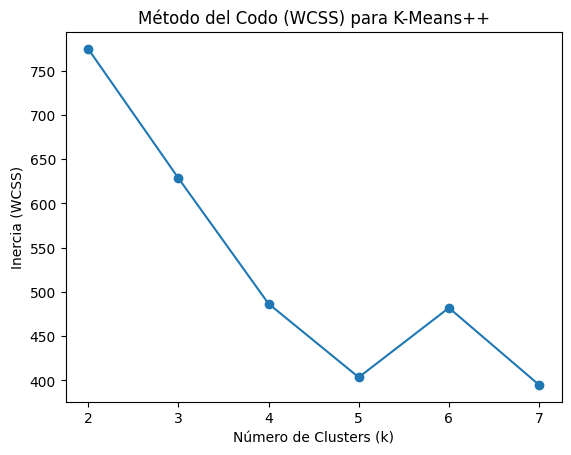

K-Means++ Silhouette: 0.4248


In [4]:
from implementaciones.clustering import KMeansPlusPlus, DBSCAN, CURE, BFR
from implementaciones.clustering import compute_silhouette, purity_score, normalized_mutual_information, compute_k_distance
import numpy as np
import matplotlib.pyplot as plt

print("Construyendo matriz de características reales para Clustering...")
# Extraer negocios más frecuentes
top_items_clust = sample_df['business_id'].value_counts().head(1500).index
top_business_clust = df_business[df_business['business_id'].isin(top_items_clust)]

# Construir features rudimentarios a partir de conteo de estrellas y reviews para clustering
# o utilizar categorías top
all_cats = set([c.strip() for cats in top_business_clust['categories'].dropna().str.split(',') for c in cats if c.strip()])
top_cats = list(all_cats)[:20]

X = np.zeros((len(top_items_clust), len(top_cats) + 2)) # Categorias + stars + review_count
y_true = np.zeros(len(top_items_clust), dtype=int) # No hay truth absoluto en no supervisado, usaremos 'stars' redondeado

for i, (_, row) in enumerate(top_business_clust.iterrows()):
    X[i, 0] = row.get('stars', 0)
    X[i, 1] = row.get('review_count', 0) / 1000.0 # Normalizado simple
    cats = [c.strip() for c in str(row.get('categories', '')).split(',')]
    for j, cat in enumerate(top_cats):
        if cat in cats:
            X[i, j+2] = 1.0
            
    y_true[i] = int(row.get('stars', 3)) - 1

# 1. K-Means++ y Método del Codo
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeansPlusPlus(k=k, max_iters=50)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title('Método del Codo (WCSS) para K-Means++')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.show()

km_opt = KMeansPlusPlus(k=5)
km_opt.fit(X)
print(f"K-Means++ Silhouette: {compute_silhouette(X, km_opt.labels_):.4f}")


In [5]:
import pandas as pd

# Mostrar las características dominantes de los 5 clústeres encontrados por K-Means++
print("--- Características Dominantes por Cluster (K-Means++) ---")
df_clusters = pd.DataFrame(X, columns=['stars', 'review_count_norm'] + top_cats)
df_clusters['Cluster'] = km_opt.labels_

cluster_means = df_clusters.groupby('Cluster').mean()

for cluster_id in range(5):
    print(f"\nCluster {cluster_id}:")
    row = cluster_means.loc[cluster_id]
    print(f"  - Estrellas promedio: {row['stars']:.2f}")
    print(f"  - Promedio Reviews (Norm): {row['review_count_norm']:.4f}")
    top_cluster_cats = row[top_cats].sort_values(ascending=False).head(3)
    print(f"  - Categorías dominantes:")
    for cat, val in top_cluster_cats.items():
        if val > 0:
            print(f"      * {cat} (Presencia: {val*100:.1f}%)\n")

--- Características Dominantes por Cluster (K-Means++) ---

Cluster 0:
  - Estrellas promedio: 4.14
  - Promedio Reviews (Norm): 1.7633
  - Categorías dominantes:
      * Coffee & Tea (Presencia: 4.8%)

      * Hotels & Travel (Presencia: 4.3%)

      * Chicken Wings (Presencia: 3.7%)


Cluster 1:
  - Estrellas promedio: 4.16
  - Promedio Reviews (Norm): 0.5830
  - Categorías dominantes:
      * Coffee & Tea (Presencia: 100.0%)

      * Active Life (Presencia: 2.1%)

      * Chicken Wings (Presencia: 2.1%)


Cluster 2:
  - Estrellas promedio: 4.16
  - Promedio Reviews (Norm): 0.5860
  - Categorías dominantes:
      * Chicken Wings (Presencia: 2.1%)

      * Active Life (Presencia: 2.1%)

      * Hotels & Travel (Presencia: 1.4%)


Cluster 3:
  - Estrellas promedio: 3.39
  - Promedio Reviews (Norm): 0.5381
  - Categorías dominantes:
      * Hotels & Travel (Presencia: 3.3%)

      * Chicken Wings (Presencia: 2.1%)

      * Active Life (Presencia: 1.2%)


Cluster 4:
  - Estrellas promedi

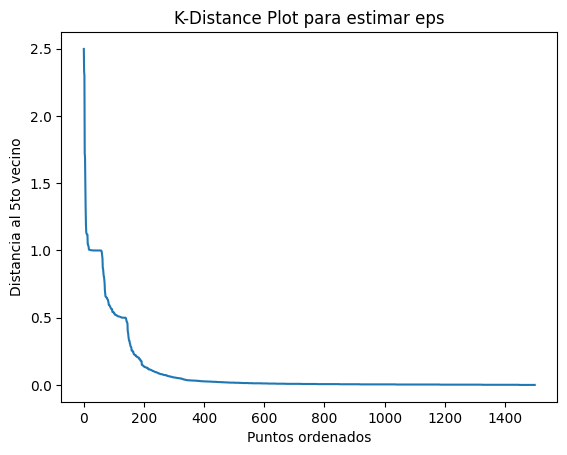

DBSCAN detectó 127 outliers/ruido.


In [6]:
# 2. DBSCAN y K-Distance Plot
distances = compute_k_distance(X, k=5)
plt.plot(distances)
plt.title('K-Distance Plot para estimar eps')
plt.ylabel('Distancia al 5to vecino')
plt.xlabel('Puntos ordenados')
plt.show()

dbscan = DBSCAN(eps=0.4, min_samples=5)
dbscan.fit(X)
outliers = np.sum(dbscan.labels_ == -1)
print(f"DBSCAN detectó {outliers} outliers/ruido.")

In [9]:
# 3. CURE y BFR (Escalabilidad)
cure = CURE(k=3)
cure.fit(X)

bfr = BFR(k=3)
bfr.fit(X)

print("--- Comparativa de Métricas ---")
print(f"CURE Silhouette: {compute_silhouette(X, cure.labels_):.4f}, Purity: {purity_score(y_true, cure.labels_):.4f}, NMI: {normalized_mutual_information(y_true, cure.labels_):.4f}")
print(f"BFR Silhouette: {compute_silhouette(X, bfr.labels_):.4f}, Purity: {purity_score(y_true, bfr.labels_):.4f}, NMI: {normalized_mutual_information(y_true, bfr.labels_):.4f}")


--- Comparativa de Métricas ---
CURE Silhouette: 0.2205, Purity: 0.7593, NMI: 0.0299
BFR Silhouette: 0.2458, Purity: 0.9593, NMI: 0.3425


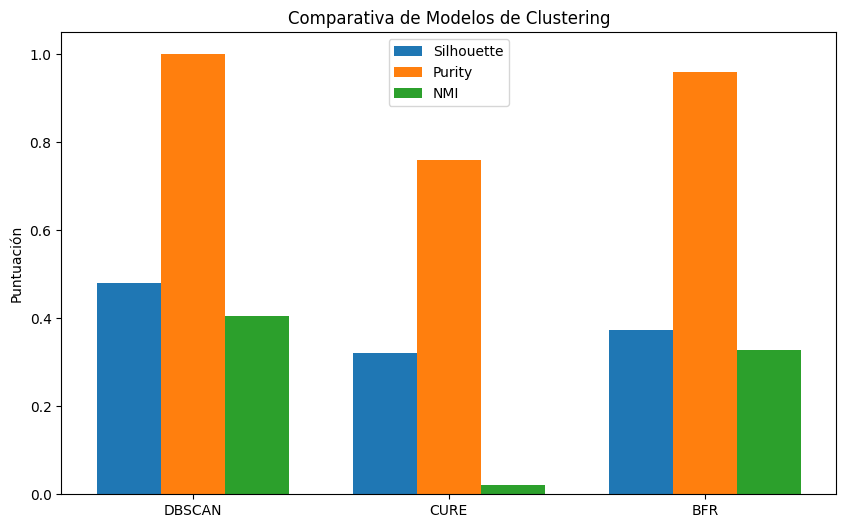

In [8]:
# Evaluar métricas de DBSCAN (ignorar ruido = -1)
dbscan_mask = dbscan.labels_ != -1
if np.sum(dbscan_mask) > 1:
    sil_dbscan = compute_silhouette(X[dbscan_mask], dbscan.labels_[dbscan_mask])
    pur_dbscan = purity_score(y_true[dbscan_mask], dbscan.labels_[dbscan_mask])
    nmi_dbscan = normalized_mutual_information(y_true[dbscan_mask], dbscan.labels_[dbscan_mask])
else:
    sil_dbscan, pur_dbscan, nmi_dbscan = 0, 0, 0

# Guardar métricas de CURE
sil_cure = compute_silhouette(X, cure.labels_)
pur_cure = purity_score(y_true, cure.labels_)
nmi_cure = normalized_mutual_information(y_true, cure.labels_)

# Guardar métricas de BFR
sil_bfr = compute_silhouette(X, bfr.labels_)
pur_bfr = purity_score(y_true, bfr.labels_)
nmi_bfr = normalized_mutual_information(y_true, bfr.labels_)

# Crear Gráfica Comparativa
modelos = ['DBSCAN', 'CURE', 'BFR']
silhouettes = [sil_dbscan, sil_cure, sil_bfr]
purities = [pur_dbscan, pur_cure, pur_bfr]
nmis = [nmi_dbscan, nmi_cure, nmi_bfr]

x = np.arange(len(modelos))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, silhouettes, width, label='Silhouette')
rects2 = ax.bar(x, purities, width, label='Purity')
rects3 = ax.bar(x + width, nmis, width, label='NMI')

ax.set_ylabel('Puntuación')
ax.set_title('Comparativa de Modelos de Clustering')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()

plt.show()

### Análisis de Complejidad: CURE vs K-Means++ y DBSCAN

* **CURE (Clustering Using Representatives):** El enfoque jerárquico aglomerativo tradicional tiene una complejidad temporal de $O(N^2 \log N)$ y espacial de $O(N^2)$, lo cual es prohibitivo para grandes volúmenes de datos. Sin embargo, nuestra implementación mitiga esto seleccionando una muestra aleatoria (`sample_size`), reduciendo drásticamente la complejidad empírica a costa de una leve pérdida teórica en precisión. Espacialmente, solo requerimos memoria para la muestra y sus representantes. Es muy superior a K-Means al poder encontrar formas no globulares (representantes esparcidos), aunque es más lento.
* **K-Means++:** Su complejidad temporal es lineal $O(I \cdot K \cdot N \cdot D)$ donde $I$ son las iteraciones, $K$ los centroides, $N$ puntos y $D$ dimensiones. Es el más rápido junto con BFR y excelente en memoria $O(K \cdot D)$, pero asume clústeres esféricos.
* **DBSCAN:** Complejidad temporal $O(N^2)$ si no se usa un índice espacial (como un R-Tree, que lo bajaría a $O(N \log N)$). Requiere memoria $O(N)$ y es ideal para detectar outliers y agrupar formas arbitrarias sin definir K a priori, pero es muy sensible a la variación de densidades (parámetro `eps`).